<a href="https://colab.research.google.com/github/carlzz01/dart.dart/blob/main/LecQuiz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

patient_name        2
sex                 0
barangay            0
visit_date          1
age                 4
weight_kg           1
height_cm           2
bp_systolic         0
temperature_c       0
diagnosis           0
follow_up_needed    0
senior_citizen      0
dtype: int64
   patient_name sex    barangay  visit_date   age weight_kg  height_cm  \
15         None   M   Poblacion  2026-01-16  -3.0       -40      169.0   
18         None   F  Bagumbayan  2026-01-19  22.0        30      132.0   

   bp_systolic  temperature_c     diagnosis follow_up_needed  senior_citizen  
15         119           36.6  Hypertension              Yes               0  
18          98           36.8   Common Cold                N               0  
(19, 12)
   patient_name sex    barangay visit_date   age        diagnosis  \
0      Delacruz   M   San Roque 2026-01-05  34.0     Hypertension   
1        Santos   F  Bagumbayan 2026-01-06   5.0      Common Cold   
2         Reyes   M   San Roque 2026-01-07   Na

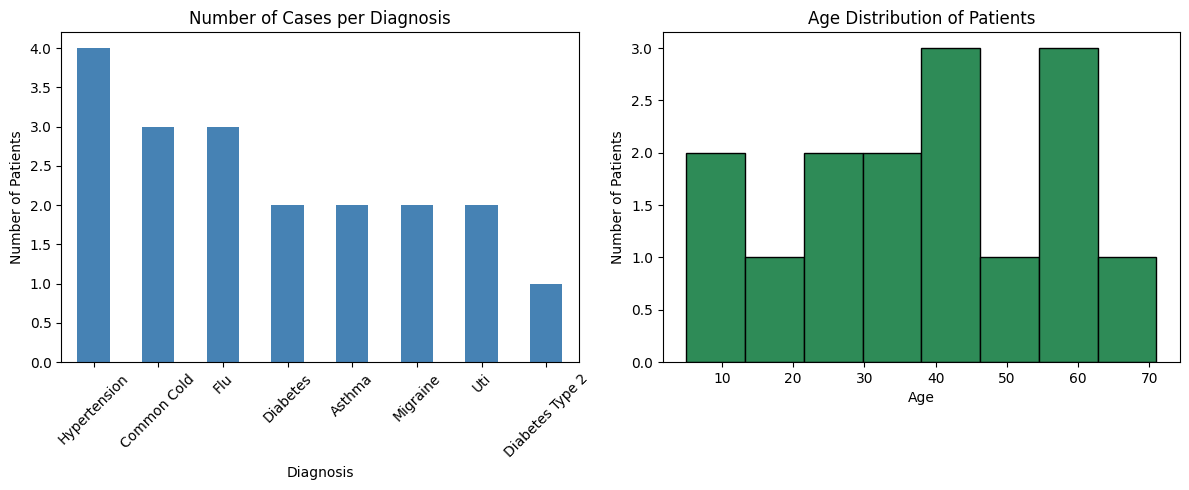

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

messy_data = {
'patient_name': ['Dela Cruz', 'Santos', 'Reyes', 'bautista', 'GARCIA ', ' Mendoza', 'Torres', 'Ramos',
    'Aquino', 'Fernandez', 'delaCruz', 'Santos', 'Villanueva', 'Domingo', 'Castro',
    None, 'Reyes', 'Navarro', None, 'Pascual', 'Torres', 'Aquino', 'Bautista', 'Cruz', 'Mercado'],
'sex': ['M','F','Male','female','M','F','m','F','M','Female','F','M','F','M','F',
    'M','F','M','F','M','F','M','F','M','F'],
'barangay': ['San Roque','Bagumbayan','san roque','Poblacion','Bagumbayan ','San Jose',
    'Poblacion','Sto. Nino','San Roque','Bagumbayan','Poblacion','San Jose',
    'Sto Nino','San Roque','Bagumbayan','Poblacion','San Roque','San Jose',
    'Bagumbayan','Poblacion','Sto. Nino','San Roque','San Jose','Bagumbayan','Poblacion'],
'visit_date': ['2026-01-05','01/06/2026','2026-1-7','2026-01-08','08-01-2026','2026-01-09',
    '2026-01-09','2026/01/10','2026-01-11','01-12-2026','2026-01-13','2026-01-13',
    '2026-01-14','2026-01-15',None,'2026-01-16','2026-01-17','2026-01-18',
    '2026-01-19','2026-01-20','2026-01-20','2026-01-21','2026-01-22','2026-01-23','2026-01-24'],
'age': [34, 5, 150, 27, np.nan, 62, 41, 8, np.nan, 29, 34, 5, 71, 45, 19, -3, 55, np.nan, 22, 38, 41, np.nan, 60, 34, 47],
'weight_kg': ['65kg','18.5','58 kg','70.2','80','45.0kg', '150', '20', '55.5', '62', '65kg', '18.5',
    '68', '75', np.nan, '-40', '90kg', '52', '30', '77', '68', '58', '95', '65kg', '61'],
'height_cm': [165, 110, 170, np.nan, 175, 150, 168, 128, 160, 172, 165, 110, 155, 180, 140,
    169, 158, np.nan, 132, 162, 168, 173, 5.9, 165, 159],
'bp_systolic': ['120','95','210','130','118','160','122','100','300','125','120','95','140',
    '135','108','119','150','127','98','131','122','128','145','120','133'],
'temperature_c': [36.5, 37.0, 39.8, 36.7, 36.6, 38.2, 36.9, 36.8, 42.5, 36.5, 36.5, 37.0,
    37.1, 36.4, 36.9, 36.6, 40.1, 36.7, 36.8, 36.9, 36.5, 37.2, 39.0, 36.5, 36.6],
'diagnosis': ['Hypertension','Common Cold','hypertension','Diabetes','COMMON COLD','Flu',
    'Hypertension ','Asthma','Diabetes Type 2','common cold','Hypertension','Common Cold',
    'Migraine','Flu','UTI','Hypertension','diabetes','Asthma','Common Cold','Flu',
    'Hypertension','Diabetes','Migrain','Hypertension','UTI'],
'follow_up_needed': ['Yes','No','yes','NO','Y','N','Yes','No','yes','No','Yes','No','No',
    'Yes','No','Yes','yes','No','N','Yes','Yes','No','Y','Yes','No'],
'senior_citizen': [0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0]
}
df = pd.DataFrame(messy_data)

print(df.isnull().sum())
missing_name = df[df['patient_name'].isnull()]
print(missing_name)

df_clean = df[df['patient_name'].notnull()].copy()

df_clean['patient_name'] = df_clean['patient_name'].str.strip().str.lower().str.replace(' ', '').str.title()
df_clean['sex'] = df_clean['sex'].str.strip().str.upper().str[0]
df_clean['barangay'] = df_clean['barangay'].str.strip().str.lower().str.replace('sto. nino', 'sto nino').str.title()
df_clean['diagnosis'] = df_clean['diagnosis'].str.strip().str.lower().str.title()
df_clean['diagnosis'] = df_clean['diagnosis'].replace({'Migrain': 'Migraine'})
df_clean['follow_up_needed'] = df_clean['follow_up_needed'].str.strip().str.upper().str[0].map({'Y': 'Yes', 'N': 'No'})

df_clean['visit_date'] = pd.to_datetime(df_clean['visit_date'], errors='coerce', format='mixed')
df_clean.loc[df_clean['patient_name'] == 'Garcia', 'visit_date'] = pd.Timestamp('2026-01-08')

df_clean['age'] = df_clean['age'].where((df_clean['age'] >= 0) & (df_clean['age'] <= 120), np.nan)

df_clean['weight_kg'] = df_clean['weight_kg'].astype(str).str.replace('kg', '', case=False).str.strip()
df_clean['weight_kg'] = pd.to_numeric(df_clean['weight_kg'], errors='coerce')
df_clean['weight_kg'] = df_clean['weight_kg'].where((df_clean['weight_kg'] > 0) & (df_clean['weight_kg'] < 300), np.nan)

df_clean['height_cm'] = df_clean['height_cm'].where(df_clean['height_cm'] >= 50, np.nan)

df_clean['bp_systolic'] = pd.to_numeric(df_clean['bp_systolic'], errors='coerce')
df_clean['bp_systolic'] = df_clean['bp_systolic'].where(df_clean['bp_systolic'] <= 250, np.nan)

df_clean['temperature_c'] = df_clean['temperature_c'].where(df_clean['temperature_c'] <= 42.0, np.nan)

df_clean = df_clean.sort_values('visit_date')
df_clean = df_clean.drop_duplicates(subset=['patient_name', 'age'], keep='first')

print(df_clean.shape)
print(df_clean[['patient_name','sex','barangay','visit_date','age','diagnosis','follow_up_needed']])

print(len(df_clean))
print(round(df_clean['age'].mean(), 1))
print(df_clean['diagnosis'].value_counts().idxmax())
print(round((df_clean['follow_up_needed']=='Yes').mean()*100, 1))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

df_clean['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Cases per Diagnosis')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df_clean['age'].dropna(), bins=8, color='seagreen', edgecolor='black')
axes[1].set_title('Age Distribution of Patients')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

1.
Column	      Missing count
patient_name	2
visit_date	  1
age	          4 (2 truly blank + 2 impossible values: 150, -3)
weight_kg	    1 (blank; -40 is a separate impossible-value issue)
height_cm	    2 (blank; 5.9 is a separate unit-error issue)

2.Is a row missing patient_name still useful?
Yes, partially. It still has valid sex, barangay, vitals, and diagnosis, so it can contribute to aggregate stats (e.g., counting hypertension cases, averaging temperature). What it can't support is anything patient-level — tracking a return visit, linking to a household, or following up with that specific person — since there's no way to identify who they are.

3.Unique barangays before vs. after cleaning
Before cleaning: 8 raw string variants ("San Roque", "san roque", "Bagumbayan", "Bagumbayan " with trailing space, "Poblacion", "San Jose", "Sto. Nino", "Sto Nino").
After standardizing case/whitespace and treating "Sto. Nino"/"Sto Nino" as the same place: 5 true barangays — Bagumbayan, Poblacion, San Jose, San Roque, Sto Nino.

4.Days with more than one visit
Yes. Three days had 2 visits each: January 8, January 9, and January 13, 2026. All other days had exactly 1 visit. It's a three-way tie for the most — no single day stands alone as highest.

5.Returning patient vs. accidental duplicate
Name and barangay alone can't tell you which it is. If every field matches exactly (same age, same vitals, same diagnosis, same date) it's almost certainly an accidental double-encode. If any clinical detail differs (different age, different diagnosis, different date), it's more likely a genuine second visit. The column that would settle it for good is a unique patient ID (or PhilHealth/national ID, or birthdate + household number) — something that identifies the person independent of how their name was typed.

6.Final df_clean summary

-Total valid patients: 22
-Average age: 36.3
-Most common diagnosis: Hypertension (6 patients)
-Percentage needing follow-up: 54.5%

7.Rows that look like duplicates
Grouping by (patient_name, barangay) flags two pairs:

Aquino (San Roque) — appears twice with identical age and diagnosis (Diabetes). This is the strongest duplicate evidence — same person, same visit, encoded twice.
Reyes (San Roque) — appears twice but with different ages and different diagnoses (Hypertension vs. Diabetes). This looks more like two different people sharing a surname, or a real second visit, not a duplicate.
Bonus case: Torres appears twice with the same age (41) and same diagnosis (Hypertension) but two different barangays — ambiguous without a patient ID.



In [ ]:
sex_map = {"m": "M", "male": "M", "f": "F", "female": "F"}
df["sex_clean"] = df["sex"].str.strip().str.lower().map(sex_map)

8.
Case sensitivity is handled by lowercasing (and trimming whitespace) first — so "M", "m", "Male", and "MALE" all collapse to the same lookup key ("m") before mapping to one canonical value. That way the dictionary only needs one entry per sex, not one per capitalization variant.

9.Should Migraine/Migrain and Diabetes/Diabetes Type 2 be merged?
"Migraine"/"Migrain" — yes, merge without hesitation; "Migrain" is just a typo, not a different condition.
"Diabetes"/"Diabetes Type 2" — more of a judgment call. Merging makes the diagnosis list simpler for a general report, which is reasonable since only 1 record specifies the subtype. But it loses clinically meaningful detail: Type 2 has a different typical patient profile and management plan than undifferentiated diabetes. Best practice is to keep a detailed column alongside the merged one so nothing is thrown away.

10.Most harmful issue if left unfixed
The ambiguous mixed-format visit dates (e.g., "08-01-2026" — is that Jan 8 or Aug 1?). Unlike cosmetic issues (capitalization) or obviously-fixable ones ("65kg"), a misread date can silently shift a patient's record to the wrong day. In a real health center, that could smear or hide an outbreak signal (several patients with fever/flu on the same actual day getting spread across different reported dates), delaying an advisory or a request for more medical staff. Duplicate entries and bad vitals distort the numbers, but a wrong date can delay real-world action.